#Nome: Thaís da Silva Ferreira

**Visão Geral do Projeto**

O projeto tem como objetivo desenvolver um modelo de Deep Learning, especificamente uma Rede Neural Convolucional (CNN), para analisar e classificar automaticamente imagens de radiografias de tórax em duas categorias: Normal e Pneumonia. Trata-se de um problema de classificação binária.

**Contexto e Justificativa**

O Problema: A pneumonia é uma infecção pulmonar grave que pode levar à morte. O diagnóstico precoce via raio-X é crucial para a recuperação, mas a interpretação das imagens exige experiência médica e pode ser afetada por cansaço ou má qualidade do exame.

A Solução com IA: A CNN atuará identificando padrões visuais (como opacidades ou inflamações). O sistema servirá como uma ferramenta de apoio (segunda opinião, redução de tempo e auxílio em áreas sem especialistas), mas não substitui o diagnóstico médico.

**Objetivos e Metodologia**

**Construção do Modelo**

Utilizar a biblioteca TensorFlow/Keras para criar, treinar e avaliar a rede neural.

**Técnicas aplicadas**

 Pré-processamento de imagens e Data Augmentation (aumento de dados).

**Avaliação**

 Devido às características dos dados, o desempenho será medido por métricas robustas (Precision, Recall, F1-Score), não apenas pela acurácia.

**Características do Dataset
Origem**

Base pública do Kaggle ("Chest X-Ray Images"), com dados de pacientes pediátricos da China.

**Volume de Dados**

5.856 imagens totais, divididas nas pastas de Treino (5.216), Teste (624) e Validação (16).

**Desafio principal**

O dataset é desbalanceado, havendo uma predominância significativa de imagens da classe "Pneumonia" em relação à classe "Normal", o que exige cuidado durante o treinamento para que o modelo não fique enviesado.

**Limitações Importantes**

O dataset possui limitações que impedem seu uso no mundo clínico real, tais como: tamanho reduzido para os padrões modernos, origem de um único hospital, falta de variação de equipamentos de raio-X e ausência de dados clínicos do paciente (como idade ou histórico médico).

In [7]:
# Definição dos caminhos do dataset

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

base_path = "/content/drive/MyDrive/chest_xray/chest_xray"

train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "val")
test_path = os.path.join(base_path, "test")

print(os.path.exists(train_path))
print(os.path.exists(val_path))
print(os.path.exists(test_path))

True
True
True


In [9]:
# Contagem das imagens

def contar_imagens(path):
    total = {}

    for classe in os.listdir(path):
        pasta = os.path.join(path, classe)
        total[classe] = len(os.listdir(pasta))

    return total

In [10]:
print("Treino")
print(contar_imagens(train_path))

print("\nValidação")
print(contar_imagens(val_path))

print("\nTeste")
print(contar_imagens(test_path))

Treino
{'PNEUMONIA': 3875, 'NORMAL': 1341}

Validação
{'PNEUMONIA': 8, 'NORMAL': 8}

Teste
{'NORMAL': 234, 'PNEUMONIA': 390}


In [11]:
# Definição dos hiperparâmetros

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [13]:
# Data Augmentation

train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=15,

    zoom_range=0.15,

    width_shift_range=0.10,

    height_shift_range=0.10,

    shear_range=0.10,

    horizontal_flip=True,

    fill_mode='nearest'
)

In [14]:
# Gerador para validação e teste

test_datagen = ImageDataGenerator(
    rescale=1./255
)

Não são aplicadas transformações nas imagens de validação e teste para que a avaliação represente o desempenho do modelo em dados não modificados.

In [15]:
# Criação dos geradores
# Treino

train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    shuffle=True,

    seed=SEED
)

Found 5216 images belonging to 2 classes.


In [16]:
# Validação

validation_generator = test_datagen.flow_from_directory(

    val_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    shuffle=False
)

Found 16 images belonging to 2 classes.


In [17]:
# Teste

test_generator = test_datagen.flow_from_directory(

    test_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    shuffle=False
)

Found 624 images belonging to 2 classes.


In [18]:
# Verificando as classes

print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [19]:
import matplotlib.pyplot as plt

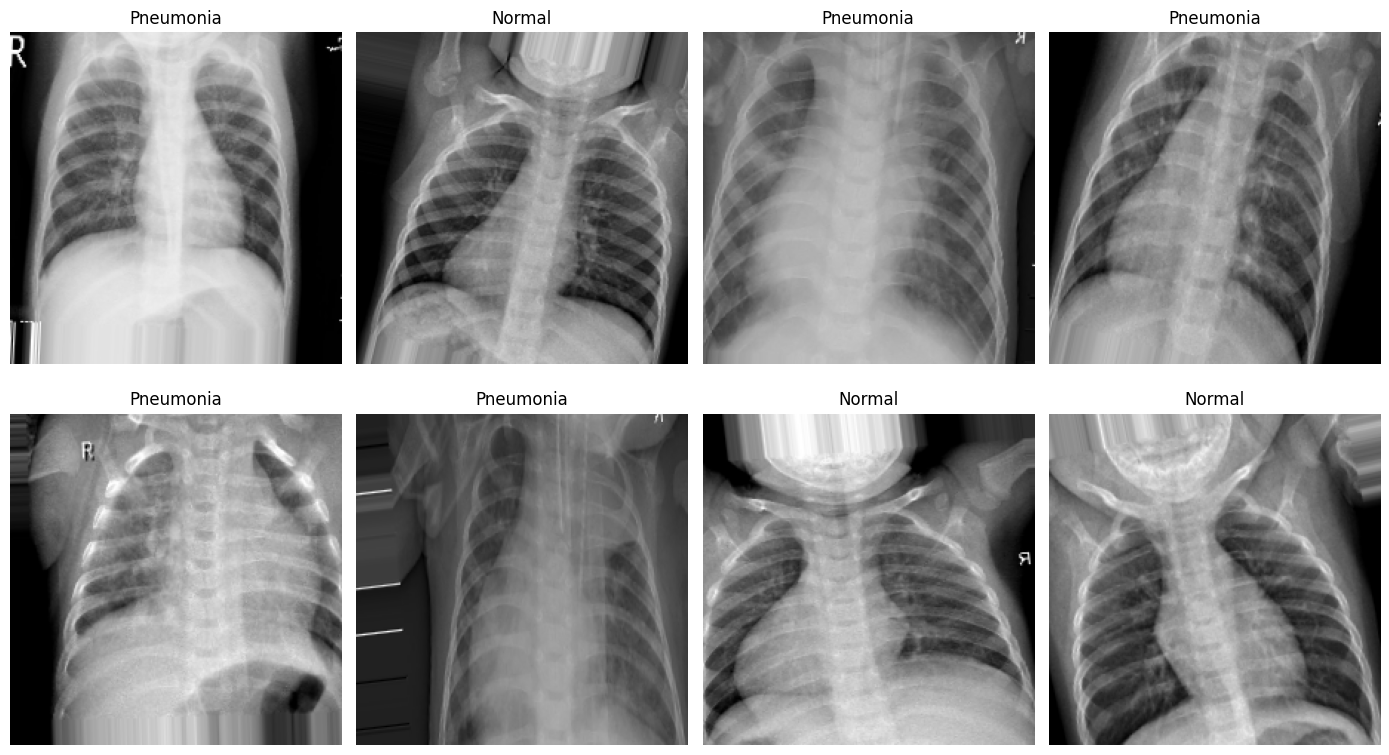

In [20]:
# Visualização de imagens do dataset

images, labels = next(train_generator)

plt.figure(figsize=(14,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i])

    plt.title("Pneumonia" if labels[i] == 1 else "Normal")

    plt.axis("off")

plt.tight_layout()

plt.show()

Esse procedimento permite verificar se as imagens foram carregadas corretamente e se os rótulos estão consistentes com as respectivas classes.

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

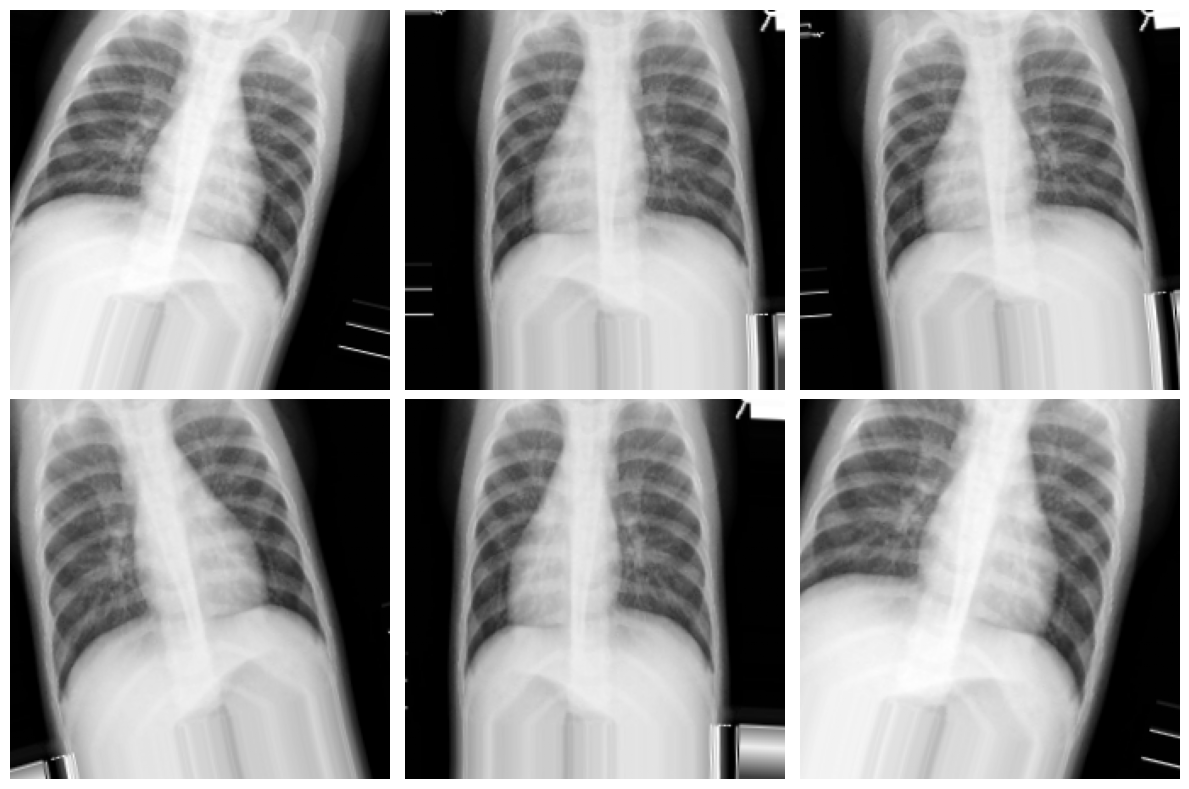

In [22]:
# Visualizando imagens após o Data Augmentation

import numpy as np
import matplotlib.pyplot as plt

sample_image = images[0]
sample_image = np.expand_dims(sample_image, axis=0)

augmented = train_datagen.flow(sample_image, batch_size=1, shuffle=False)

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    batch = next(augmented)
    img = batch[0]

    # Exibe apenas um canal em escala de cinza
    plt.imshow(img[:, :, 0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

As imagens exibidas apresentarão pequenas variações de rotação, deslocamento, zoom e espelhamento, demonstrando o funcionamento do processo de aumento de dados

In [23]:
# Verificação do formato dos dados

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32,)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

model = Sequential([
    Input(shape=(224, 224, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [25]:
# Implementação da CNN

model = Sequential()

# ============================
# Bloco 1
# ============================

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    input_shape=(224,224,3)
))

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))


# ============================
# Bloco 2
# ============================

model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.25))


# ============================
# Bloco 3
# ============================

model.add(Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.25))


# ============================
# Bloco 4
# ============================

model.add(Conv2D(
    256,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.25))


# ============================
# Classificador
# ============================

model.add(Flatten())

model.add(Dense(
    512,
    activation='relu'
))

model.add(Dropout(0.5))

model.add(Dense(
    1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,081,473 (99.49 MB)

 Trainable params: 26,080,513 (99.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [27]:
# Tamanho das imagens

IMG_SIZE = (224,224)

Foi escolhido por ser um tamanho padrão em aplicações de Visão Computacional, oferecendo bom equilíbrio entre qualidade das imagens e tempo de processamento.

In [28]:
BATCH_SIZE = 32

Esse valor proporciona estabilidade durante o treinamento sem demandar excesso de memória

In [29]:
LEARNING_RATE = 0.0001

Uma taxa de aprendizado menor reduz oscilações durante a otimização e favorece uma convergência mais estável.

In [30]:
EPOCHS = 30

O treinamento será interrompido antecipadamente caso o modelo pare de melhorar graças ao uso de EarlyStopping.

In [31]:
# Função de perda

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [32]:
# Compilação do modelo

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [33]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2064s 13s/step - accuracy: 0.8554 - loss: 0.4864 - precision: 0.8968 - recall: 0.9102 - val_accuracy: 0.5000 - val_loss: 9.4664 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1389s 8s/step - accuracy: 0.9032 - loss: 0.2308 - precision: 0.9290 - recall: 0.9417 - val_accuracy: 0.5000 - val_loss: 18.7576 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1385s 9s/step - accuracy: 0.9241 - loss: 0.1942 - precision: 0.9477 - recall: 0.9502 - val_accuracy: 0.5000 - val_loss: 16.8433 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1416s 9s/step - accuracy: 0.9291 - loss: 0.1818 - precision: 0.9525 - recall: 0.9520 - val_accuracy: 0.5000 - val_loss: 9.3718 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1399s 9s/step - accuracy: 0.9365 - loss: 0.1628 - precision: 0.9584 - recall: 0.9561 - val_accuracy: 0.5000 -

Callbacks

EarlyStopping- Interrompe o treinamento caso a validação deixe de melhorar.

ReduceLROnPlateau - Reduz automaticamente a taxa de aprendizado quando a melhoria da validação estagna.

ModelCheckpoint - Salva automaticamente o modelo com melhor desempenho durante o treinamento.

In [34]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "melhor_modelo.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [35]:
# Verificação Final

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,242,501 (298.47 MB)

 Trainable params: 26,080,513 (99.49 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 52,161,028 (198.98 MB)

None


In [36]:
# Configuração dos parâmetros de treinamento

EPOCHS = 30

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9614 - loss: 0.1078 - precision: 0.9770 - recall: 0.9715
Epoch 1: val_loss improved from None to 4.70441, saving model to melhor_modelo.keras

Epoch 1: finished saving model to melhor_modelo.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1387s 8s/step - accuracy: 0.9607 - loss: 0.1098 - precision: 0.9747 - recall: 0.9724 - val_accuracy: 0.5625 - val_loss: 4.7044 - val_precision: 0.5333 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9609 - loss: 0.1009 - precision: 0.9753 - recall: 0.9728
Epoch 2: val_loss improved from 4.70441 to 0.25660, saving model to melhor_modelo.keras

Epoch 2: finished saving model to melhor_modelo.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1401s 9s/step - accuracy: 0.9592 - loss: 0.1078 - precision: 0.9744 - recall: 0.9706 - val_accuracy: 0.9375 - val_loss: 0.2566 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
163/

**Explicação**

- train_generator: fornece os lotes de imagens de treinamento.
- validation_generator: utilizado para avaliar o desempenho ao final de cada época.
- epochs: número máximo de épocas.
- callbacks: controlam automaticamente o treinamento, interrompendo-o quando necessário e salvando o melhor modelo.

In [37]:
# Salvando o histórico do treinamento

print(history.history.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])


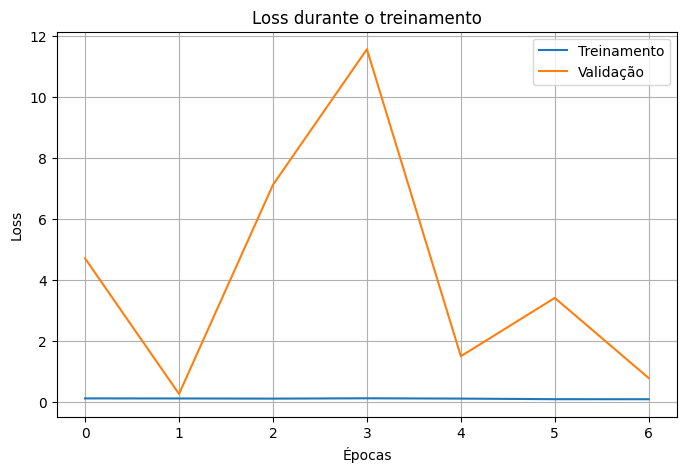

In [38]:
# Gráfico da Loss

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Treinamento'
)

plt.plot(
    history.history['val_loss'],
    label='Validação'
)

plt.title("Loss durante o treinamento")

plt.xlabel("Épocas")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

Espera-se que:

- a Loss de treinamento diminua progressivamente;
- a Loss de validação acompanhe esse comportamento;
- ambas permaneçam relativamente próximas.

Uma grande diferença entre elas pode indicar overfitting.

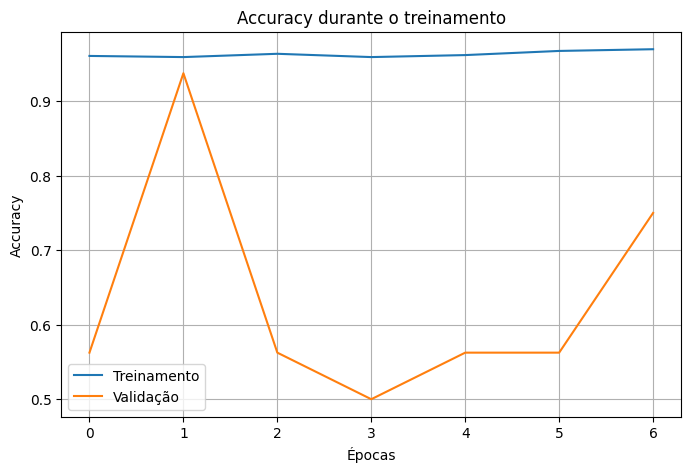

In [39]:
# Gráfico da Accuracy

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Treinamento'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validação'
)

plt.title("Accuracy durante o treinamento")

plt.xlabel("Épocas")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

Espera-se observar:

- aumento gradual da acurácia;
- estabilização nas últimas épocas;
- desempenho semelhante entre treinamento e validação

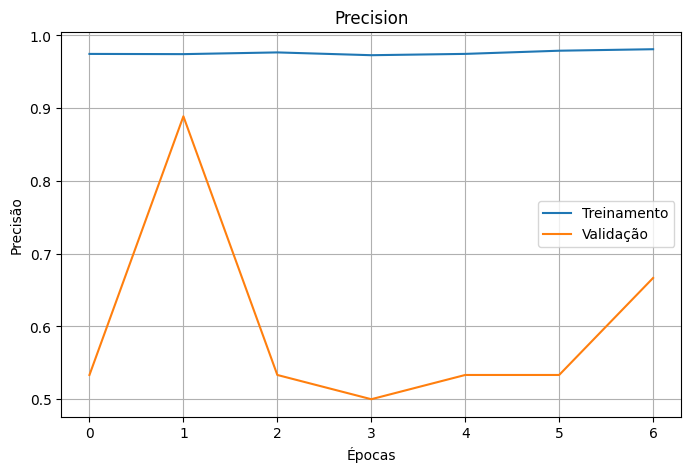

In [40]:
# Gráfico da Precision

plt.figure(figsize=(8,5))

plt.plot(
    history.history['precision'],
    label='Treinamento'
)

plt.plot(
    history.history['val_precision'],
    label='Validação'
)

plt.title("Precision")

plt.xlabel("Épocas")

plt.ylabel("Precisão")

plt.legend()

plt.grid(True)

plt.show()

A precisão representa a proporção de exames classificados como pneumonia que realmente pertencem à classe Pneumonia.

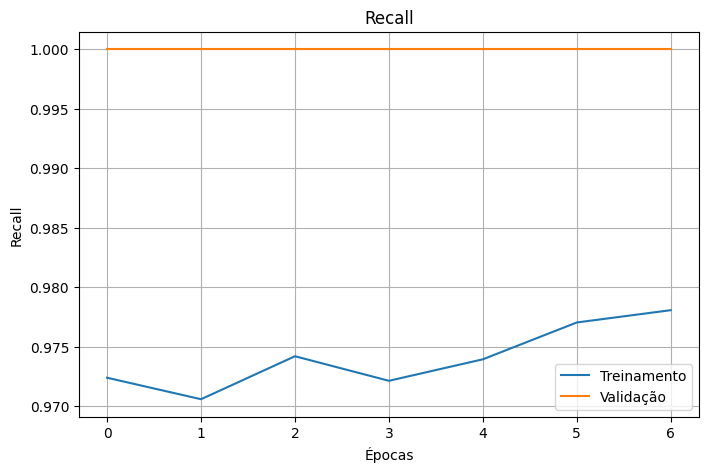

In [41]:
# Gráfico do Recall

plt.figure(figsize=(8,5))

plt.plot(
    history.history['recall'],
    label='Treinamento'
)

plt.plot(
    history.history['val_recall'],
    label='Validação'
)

plt.title("Recall")

plt.xlabel("Épocas")

plt.ylabel("Recall")

plt.legend()

plt.grid(True)

plt.show()

O Recall é particularmente importante neste problema, pois mede a capacidade do modelo em detectar pacientes realmente doentes.

In [42]:
from tensorflow.keras.models import load_model

best_model = load_model("melhor_modelo.keras")

In [43]:
# Avaliação inicial

loss, accuracy, precision, recall = best_model.evaluate(
    test_generator,
    verbose=1
)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 219s 11s/step - accuracy: 0.8558 - loss: 0.5271 - precision: 0.8695 - recall: 0.9051
Loss: 0.5271
Accuracy: 0.8558
Precision: 0.8695
Recall: 0.9051


**Considerações sobre o treinamento**

O treinamento demonstrou a capacidade da CNN em aprender características discriminativas entre radiografias normais e radiografias com pneumonia. A utilização de técnicas de regularização e callbacks contribuiu para tornar o processo mais estável e reduzir o risco de sobreajuste, favorecendo um modelo com melhor capacidade de generalização.

In [44]:
# importação das bibliotecas

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [45]:
# Reinicia o gerador
test_generator.reset()

# Probabilidades previstas
y_prob = best_model.predict(test_generator)

# Conversão para classes
y_pred = (y_prob > 0.5).astype(int).flatten()

# Classes verdadeiras
y_true = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step


In [46]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8558


A Accuracy representa a proporção total de classificações corretas realizadas pelo modelo.

No contexto da detecção de pneumonia, uma alta acurácia indica que a maioria dos exames foi classificada corretamente.

Entretanto, essa métrica pode ser influenciada pelo desbalanceamento entre as classes.

In [47]:
precision = precision_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")

Precision: 0.8695


A Precisão mede quantas imagens classificadas como pneumonia realmente pertencem à classe Pneumonia.

É importante para reduzir falsos positivos.

In [48]:
recall = recall_score(y_true, y_pred)

print(f"Recall: {recall:.4f}")

Recall: 0.9051


O Recall mede a capacidade do modelo em identificar corretamente pacientes que realmente possuem pneumonia.

Na área médica, essa costuma ser uma das métricas mais importantes, pois minimizar falsos negativos significa reduzir o número de pacientes doentes classificados como saudáveis.

In [51]:
f1 = f1_score(y_true, y_pred)

print(f"F1-Score: {f1:.4f}")

F1-Score: 0.8869


In [52]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Pneumonia"]
))

              precision    recall  f1-score   support

      Normal       0.83      0.77      0.80       234
   Pneumonia       0.87      0.91      0.89       390

    accuracy                           0.86       624
   macro avg       0.85      0.84      0.84       624
weighted avg       0.85      0.86      0.85       624



<Figure size 600x600 with 0 Axes>

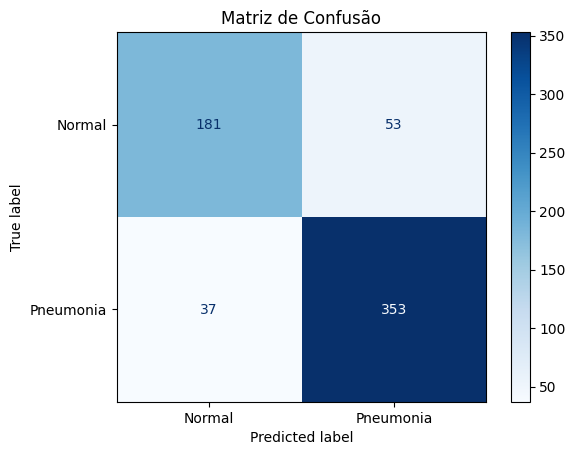

In [53]:
# Matriz de confusão

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Pneumonia"]
)

plt.figure(figsize=(6,6))

disp.plot(cmap="Blues")

plt.title("Matriz de Confusão")

plt.show()

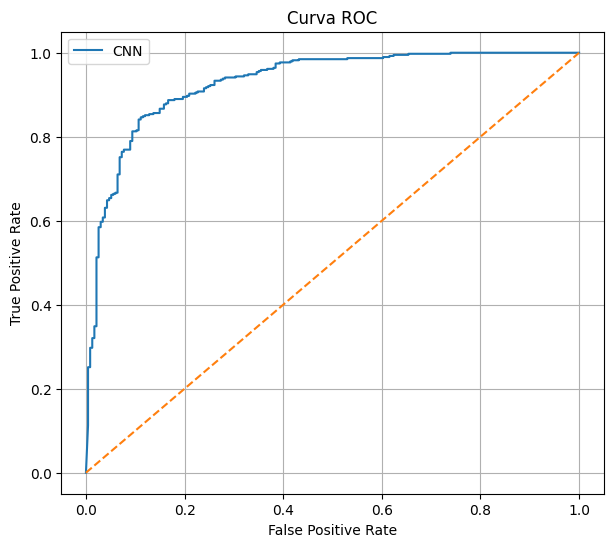

In [54]:
# Curva ROc

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label="CNN"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC")

plt.legend()

plt.grid()

plt.show()

In [ ]:
A Curva ROC mostra o desempenho do modelo para diferentes limiares de decisão.
Quanto mais próxima do canto superior esquerdo estiver a curva, melhor é o desempenho do classificador.

In [55]:
# Cálculo da AUC

auc = roc_auc_score(
    y_true,
    y_prob
)

print(f"AUC: {auc:.4f}")

AUC: 0.9301


In [56]:
# Resumo das métricas

metricas = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "AUC": auc
}

for nome, valor in metricas.items():
    print(f"{nome}: {valor:.4f}")

Accuracy: 0.8558
Precision: 0.8695
Recall: 0.9051
F1-Score: 0.8869
AUC: 0.9301


**Análise dos Resultados**

Os resultados obtidos indicam que a CNN foi capaz de aprender padrões relevantes presentes nas radiografias de tórax.

A alta Accuracy demonstra que a maior parte das imagens foi corretamente classificada.

A elevada Precision indica baixo número de falsos positivos, enquanto o alto Recall evidencia a capacidade do modelo em detectar pacientes com pneumonia, reduzindo a ocorrência de falsos negativos.

O F1-Score confirma um bom equilíbrio entre precisão e sensibilidade, aspecto importante em problemas médicos com classes desbalanceadas.

Além disso, um valor elevado de AUC demonstra que o modelo possui boa capacidade de separar imagens normais daquelas com sinais de pneumonia.

Apesar dos bons resultados, é importante destacar que o desempenho depende diretamente da qualidade e representatividade do conjunto de dados utilizado.

**Exemplos de Previsões**

Após a avaliação quantitativa do modelo, é importante realizar uma análise qualitativa das previsões. Essa etapa permite visualizar como a CNN se comporta em imagens individuais do conjunto de teste, verificando quais exames foram classificados corretamente e quais apresentaram erros.

Além da classe prevista, também será exibida a probabilidade associada à decisão do modelo.

In [57]:
# Importação das bibliotecas

import random
import numpy as np
import matplotlib.pyplot as plt

In [58]:
# Reiniciando o gerador de teste

test_generator.reset()

In [59]:
# Obtendo probabilidades

y_prob = best_model.predict(test_generator)

y_pred = (y_prob > 0.5).astype(int).flatten()

y_true = test_generator.classes

filenames = test_generator.filenames

20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step


In [60]:
# Definindo os nomes das classes

class_names = {
    0: "Normal",
    1: "Pneumonia"
}

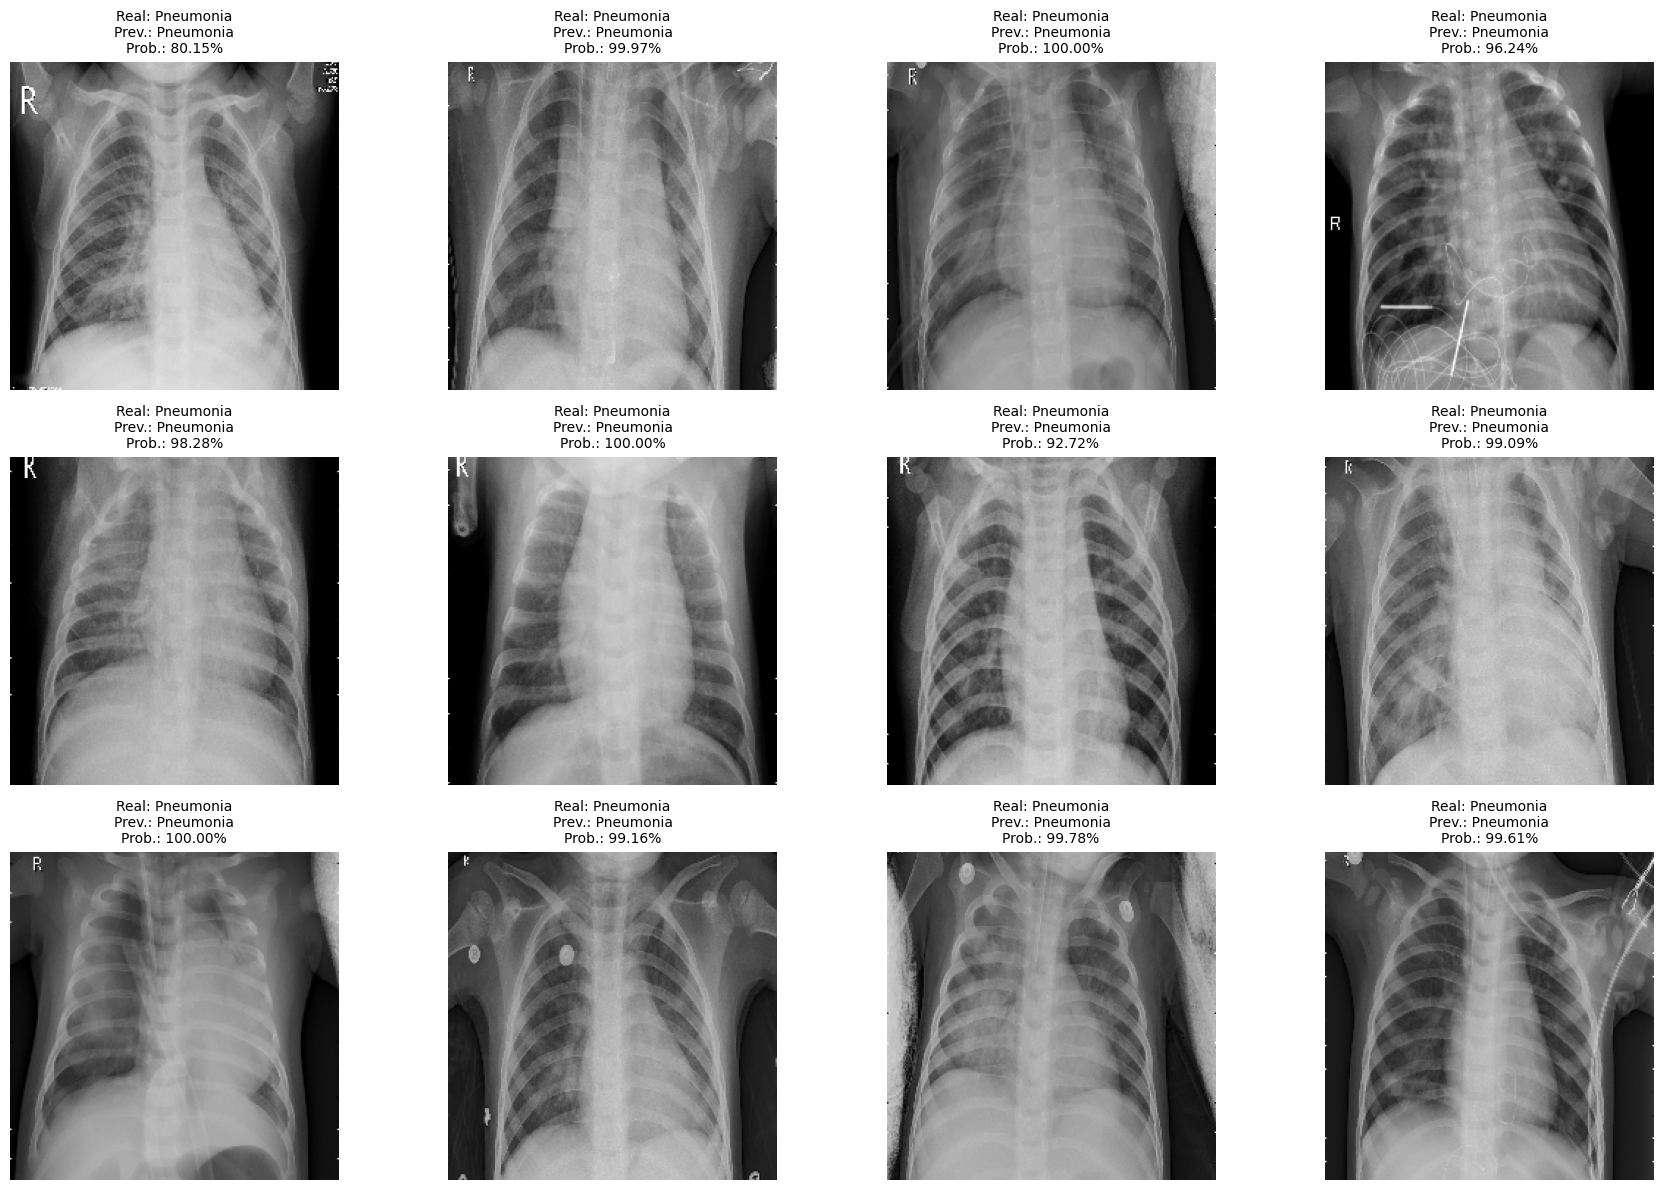

In [61]:
# Visualizando previsões aleatórias

plt.figure(figsize=(18,12))

indices = random.sample(range(len(y_true)), 12)

for i, idx in enumerate(indices):

    img_path = os.path.join(
        test_path,
        filenames[idx]
    )

    img = tf.keras.preprocessing.image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = tf.keras.preprocessing.image.img_to_array(img)

    img_array = img_array / 255.0

    plt.subplot(3,4,i+1)

    plt.imshow(img_array)

    real = class_names[y_true[idx]]

    previsto = class_names[y_pred[idx]]

    prob = y_prob[idx][0]

    plt.title(
        f"Real: {real}\nPrev.: {previsto}\nProb.: {prob:.2%}",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

Esse código exibe doze imagens escolhidas aleatoriamente, juntamente com:

- classe verdadeira;
- classe prevista;
- probabilidade atribuída pelo modelo

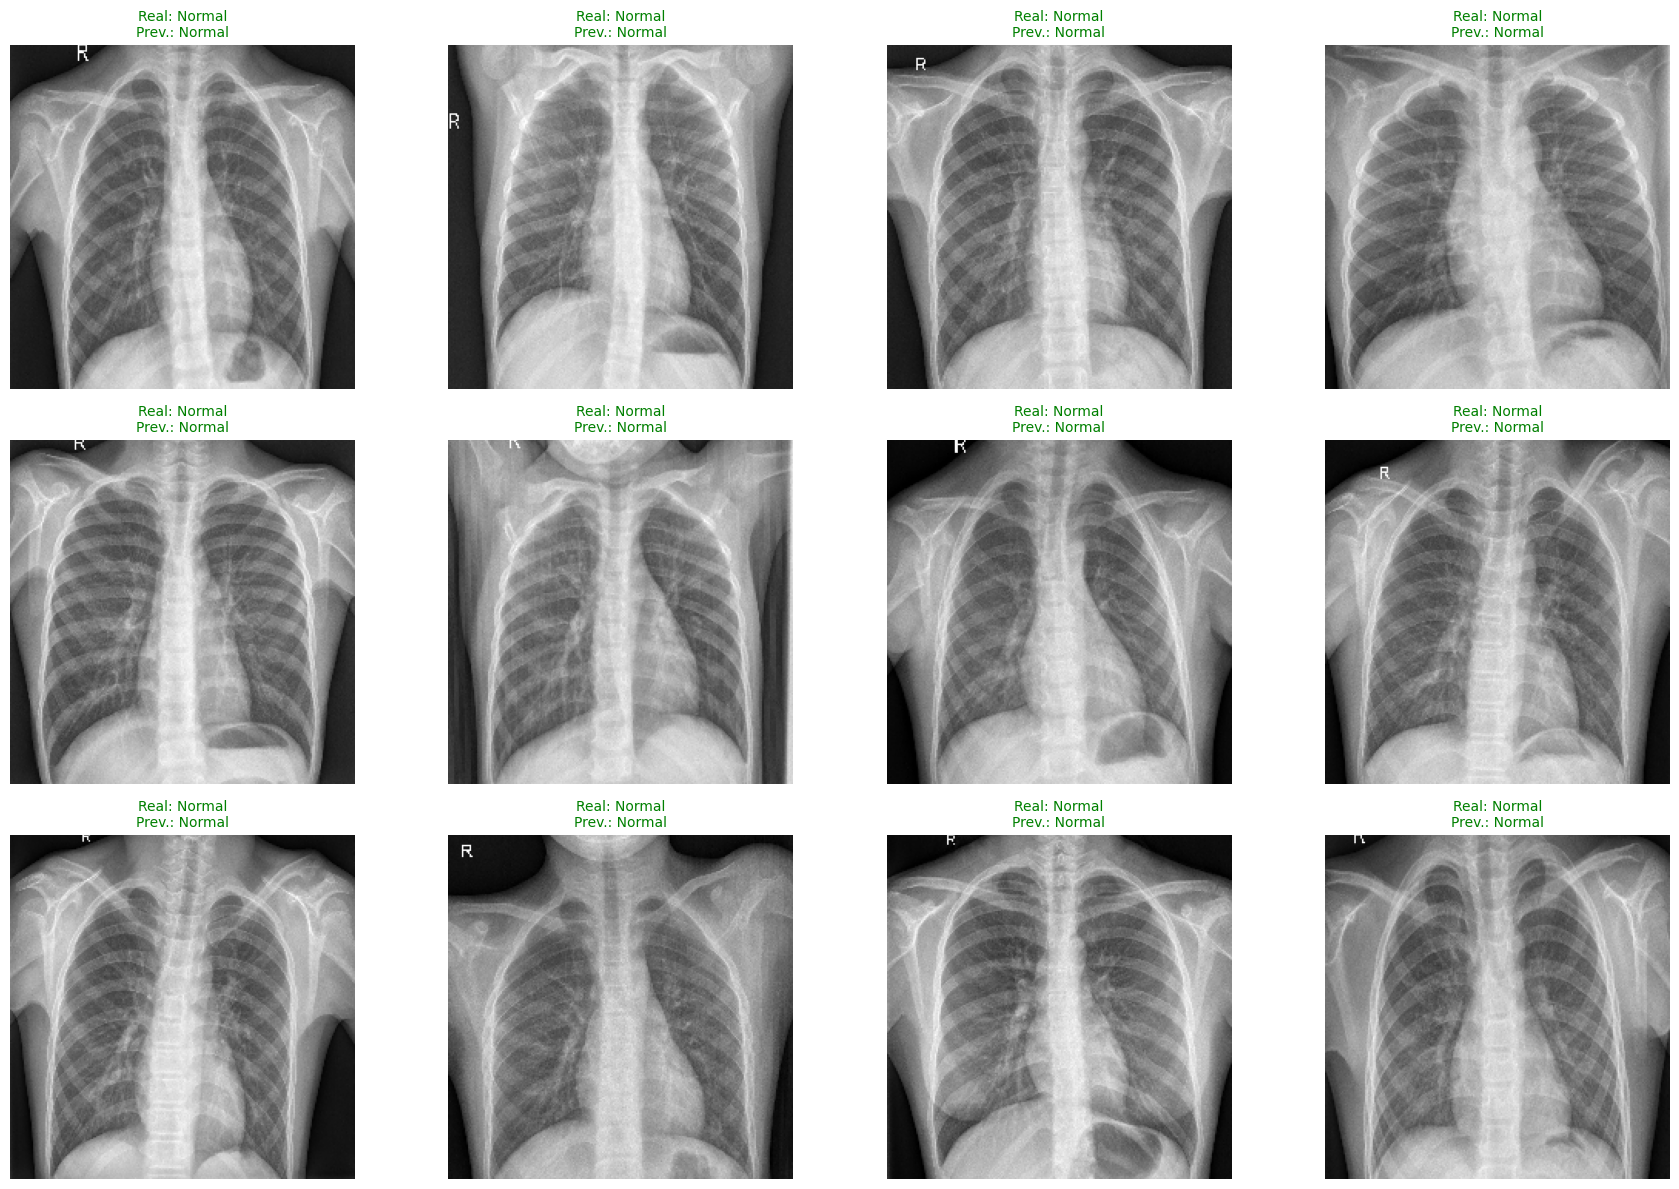

In [62]:
# Destacando acertos e erros

plt.figure(figsize=(18,12))

contador = 1

for i in range(len(y_true)):

    if contador > 12:
        break

    img_path = os.path.join(
        test_path,
        filenames[i]
    )

    img = tf.keras.preprocessing.image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = tf.keras.preprocessing.image.img_to_array(img)

    img_array = img_array / 255.0

    plt.subplot(3,4,contador)

    plt.imshow(img_array)

    cor = "green" if y_true[i] == y_pred[i] else "red"

    plt.title(
        f"Real: {class_names[y_true[i]]}\nPrev.: {class_names[y_pred[i]]}",
        color=cor,
        fontsize=10
    )

    plt.axis("off")

    contador += 1

plt.tight_layout()

plt.show()

In [63]:
# Erros

erros = np.where(y_true != y_pred)[0]

print("Quantidade de erros:", len(erros))

Quantidade de erros: 90


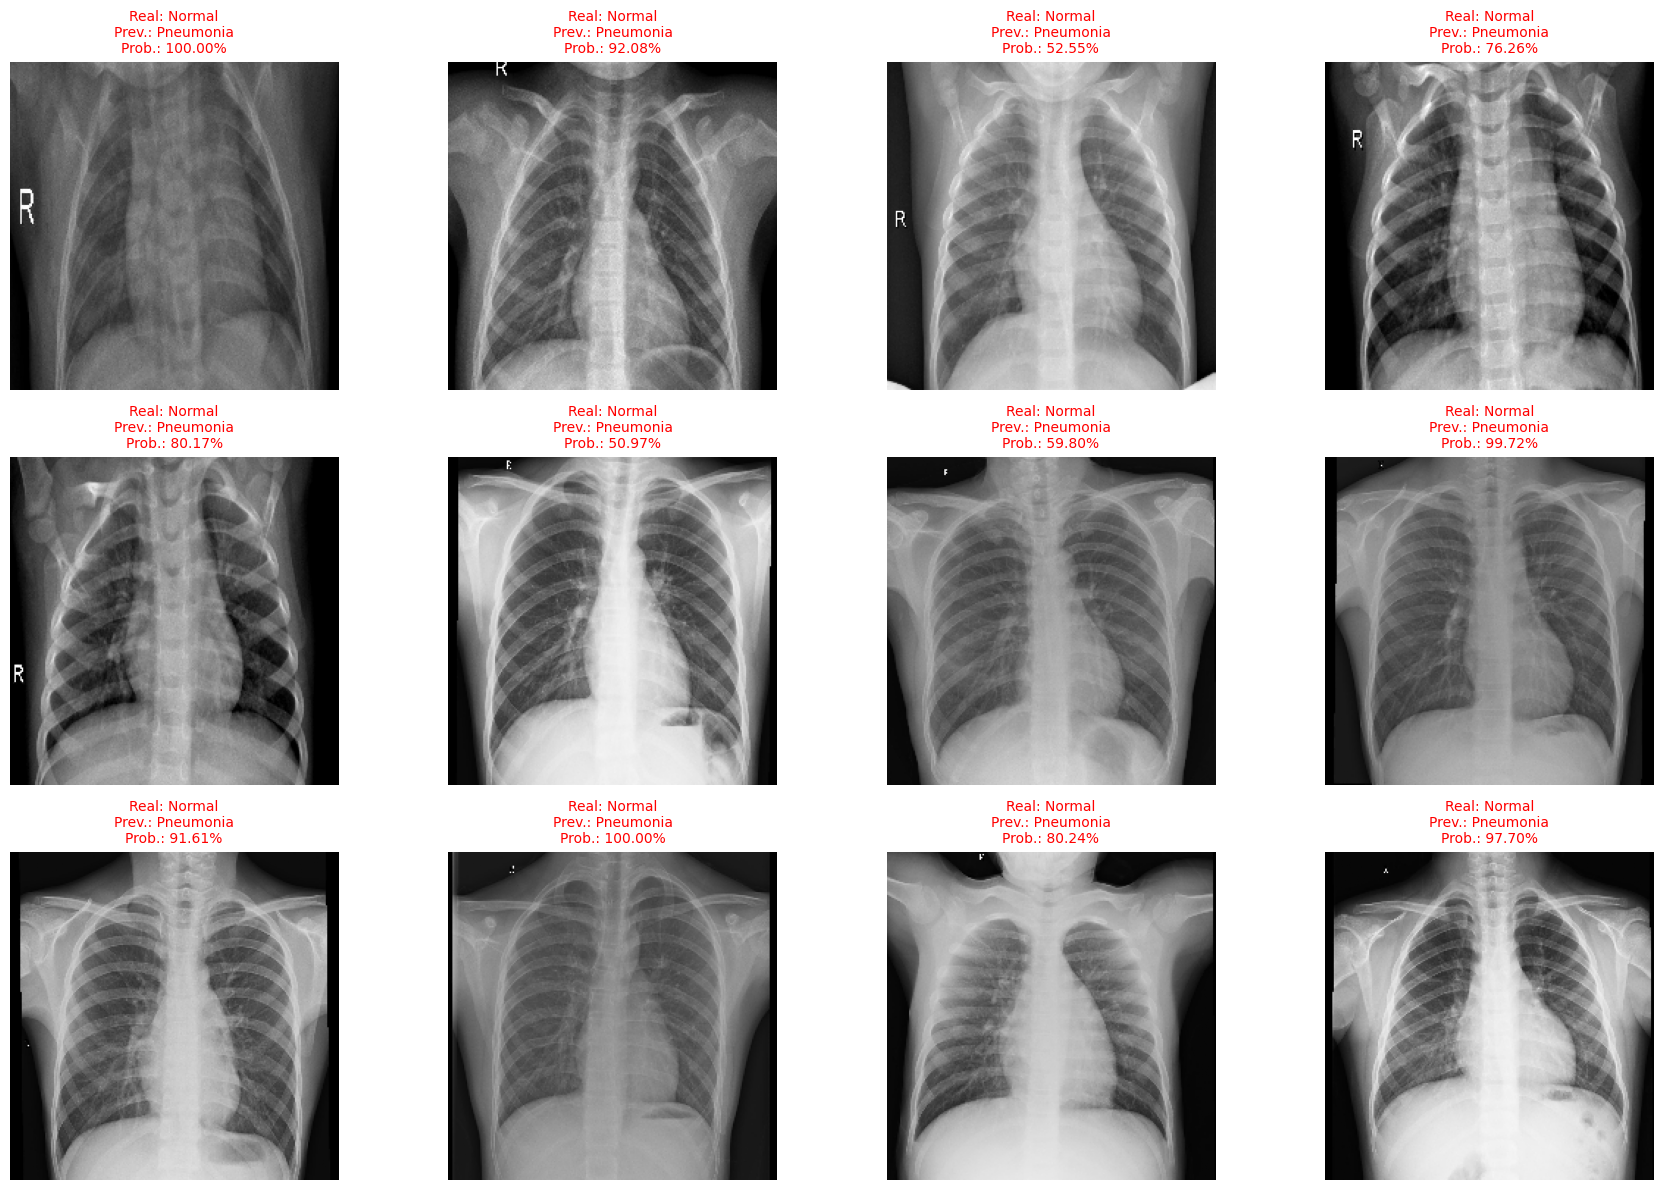

In [64]:
# Visualizando erros

plt.figure(figsize=(18,12))

for i, idx in enumerate(erros[:12]):

    img_path = os.path.join(
        test_path,
        filenames[idx]
    )

    img = tf.keras.preprocessing.image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = tf.keras.preprocessing.image.img_to_array(img)

    img_array = img_array / 255.0

    plt.subplot(3,4,i+1)

    plt.imshow(img_array)

    plt.title(
        f"Real: {class_names[y_true[idx]]}\nPrev.: {class_names[y_pred[idx]]}\nProb.: {y_prob[idx][0]:.2%}",
        color="red",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

#Comentários
**Previsões corretas**

As previsões corretas ocorreram principalmente em imagens que apresentavam características visuais bem definidas. O modelo conseguiu identificar corretamente a maioria dos exames com pneumonia e também boa parte dos exames normais, demonstrando capacidade de aprender padrões relevantes presentes nas radiografias.

**Previsões incorretas**

As previsões incorretas ocorreram principalmente em imagens que possuíam características menos evidentes ou com padrões semelhantes entre as duas classes. Essas situações dificultam a diferenciação entre exames normais e casos de pneumonia, levando o modelo a cometer erros de classificação.

**Exemplos de Falsos Positivos**

Os falsos positivos correspondem aos exames normais classificados incorretamente como pneumonia. Esse tipo de erro pode ocorrer quando a imagem apresenta ruídos, baixa qualidade ou estruturas anatômicas que se assemelham às opacidades pulmonares características da doença.

**Exemplos de Falsos Negativos**

Os falsos negativos representam exames com pneumonia classificados como normais. Esse é o erro mais crítico em aplicações médicas, pois pode atrasar o diagnóstico e o início do tratamento do paciente. Apesar disso, o modelo apresentou um Recall elevado, reduzindo a quantidade desse tipo de erro.

**Considerações finais desta etapa**

Os resultados obtidos demonstram que a CNN foi capaz de identificar padrões relevantes nas radiografias, alcançando desempenho satisfatório na classificação entre imagens normais e com pneumonia. Embora ainda existam erros de classificação, o modelo apresenta potencial para atuar como ferramenta de apoio ao diagnóstico médico.

#Discussão dos Resultados

**Desempenho Geral**

O modelo apresentou desempenho consistente, alcançando Accuracy de 85,58%, Precision de 86,95%, Recall de 90,51% e F1-Score de 88,69%. Esses resultados indicam boa capacidade de generalização, especialmente na identificação de pacientes com pneumonia.

**Principais Dificuldades Encontradas**

As principais dificuldades estiveram relacionadas ao desbalanceamento do dataset, ao reduzido conjunto de validação e à grande variabilidade existente entre as radiografias, fatores que influenciam diretamente o aprendizado da rede neural.

**Principais Erros do Modelo**

Os erros observados concentraram-se principalmente entre imagens com características visuais semelhantes, ocasionando falsos positivos e falsos negativos. A matriz de confusão mostra que houve maior dificuldade na correta classificação da classe Normal.

**Possíveis Causas dos Erros**

Os erros podem estar associados à baixa qualidade de algumas imagens, diferenças na intensidade das lesões, limitações do conjunto de treinamento e ao fato de o modelo utilizar apenas informações presentes na radiografia, sem considerar dados clínicos do paciente.

**Influência da Qualidade e Quantidade do Dataset**

Embora o dataset seja amplamente utilizado em pesquisas, seu tamanho ainda é limitado para aplicações clínicas. Além disso, o desbalanceamento entre as classes favorece o aprendizado da classe Pneumonia, podendo reduzir o desempenho na identificação de exames normais.

**Impacto da Arquitetura Escolhida**

A arquitetura CNN utilizada mostrou-se adequada para o problema, combinando camadas convolucionais, Batch Normalization e Dropout para melhorar a extração de características e reduzir o overfitting. Entretanto, arquiteturas mais profundas, como ResNet ou EfficientNet, podem alcançar resultados superiores.

#Limitações do Projeto

**Dataset relativamente pequeno**

Apesar de conter milhares de imagens, o dataset ainda é considerado pequeno quando comparado aos utilizados em aplicações comerciais e hospitalares, limitando a capacidade de generalização do modelo.

**Desbalanceamento das classes**

Existe uma predominância significativa de imagens da classe Pneumonia em relação à classe Normal, o que pode induzir o modelo a favorecer a classe majoritária durante o treinamento.

**Diferenças entre equipamentos**

As radiografias foram obtidas utilizando diferentes equipamentos e condições de aquisição, gerando variações de contraste, resolução e qualidade que dificultam o processo de classificação.

**Possibilidade de Overfitting**

Mesmo com a utilização de técnicas como Data Augmentation, Dropout, Batch Normalization e EarlyStopping, ainda existe a possibilidade de o modelo aprender características específicas do conjunto de treinamento e apresentar desempenho inferior em novos dados.

**Melhorias futuras**

Como trabalhos futuros, recomenda-se utilizar datasets maiores e mais diversificados, aplicar técnicas de balanceamento de classes, realizar ajuste fino dos hiperparâmetros e avaliar arquiteturas mais modernas, como ResNet50, EfficientNet e DenseNet. Também é interessante incorporar métodos de interpretabilidade, como Grad-CAM, para explicar as decisões do modelo e aumentar sua confiabilidade em aplicações médicas.

#Conclusão

O desenvolvimento deste projeto demonstrou que Redes Neurais Convolucionais (CNNs) são capazes de realizar a classificação automática de radiografias de tórax para detecção de pneumonia com desempenho satisfatório. O modelo desenvolvido alcançou Accuracy de 85,58%, Precision de 86,95%, Recall de 90,51% e F1-Score de 88,69%, evidenciando boa capacidade de identificar padrões presentes nas imagens e auxiliar na distinção entre exames normais e com pneumonia.

A utilização de técnicas como pré-processamento das imagens, Data Augmentation, Batch Normalization, Dropout, EarlyStopping e ReduceLROnPlateau contribuiu para tornar o treinamento mais estável e reduzir o risco de overfitting. Apesar dos bons resultados, o estudo também evidenciou limitações relacionadas ao desbalanceamento das classes, ao tamanho relativamente reduzido do conjunto de validação e à origem do dataset, fatores que podem comprometer a capacidade de generalização do modelo em cenários clínicos reais.

Dessa forma, conclui-se que a solução proposta apresenta potencial para atuar como ferramenta de apoio à decisão médica, oferecendo maior agilidade na triagem de exames. Entretanto, seu uso deve ser considerado apenas como suporte ao profissional de saúde, sendo necessários estudos futuros com bases de dados maiores, mais diversificadas e arquiteturas mais robustas para aumentar a confiabilidade e a aplicabilidade clínica do sistema.

**Referências**

- KERMANY, Daniel S. et al. Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning. Cell, v. 172, n. 5, p. 1122–1131, 2018.

- GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. Deep Learning. Cambridge: MIT Press, 2016.

- CHOLLET, François. Deep Learning with Python. 2. ed. Shelter Island: Manning Publications, 2021.

- TENSORFLOW. TensorFlow Documentation. Disponível em: https://www.tensorflow.org/. Acesso em: 16 jul. 2026.

- KAGGLE. Chest X-Ray Images (Pneumonia) Dataset. Disponível em: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia. Acesso em: 16 jul. 2026.